In [17]:
import numpy as np

class SVM:
    def __init__(self, lr=0.001, C=1.0, n_iters=1000):
        self.lr = lr
        self.C = C
        self.n_iters = n_iters
        self.w = None
        self.b = None
    
    def fit(self, X, y):
        # y를 +1, -1로 변환
        y_ = np.where(y<=0,-1,1)
        n_samples, n_features = X.shape

        # 파라미터 초기화
        self.w = np.zeros(n_features)
        self.b = 0

        # 경사하강법 루프
        for _ in range(self.n_iters):
            for idx, x_i in enumerate(X):
                self._update(x_i, y_[idx])
        
    def predict(self, X):
        scores = np.dot(X, self.w) + self.b
        return np.sign(scores)
    
    def _update(self, x_i, y_i):
        # 마진 조건 확인
        condition = y_i * (np.dot(x_i, self.w) + self.b) >= 1

        if condition:
            # 분류 성공 : 정규화 항만 업데이트
            self.w -= self.lr*(2*self.w)
            self.b -= self.lr*(-self.C*y_i)
        else:
            # 실패(또는 마진 침범): 가중치 규제 + 오차 교정
            # 공식: w = w - lr * (2 * w - C * y_i * x_i)
            self.w -= self.lr * (2 * self.w - self.C * y_i * x_i)
            # 공식: b = b - lr * (-y_i) => 즉, b = b + lr * y_i
            self.b -= self.lr * (-y_i)
        
    # 전체 클래스에 추가할 시각화 헬퍼
    def decision_boundary(self, x):
        # 결정 경계의 y값 반환 (2D 시각화용)
        return -(self.w[0] * x + self.b) / self.w[1]
    
    def margin_lines(self, x):
        # 마진 경계선 반환
        upper = (-self.w[0] * x - self.b + 1) / self.w[1]
        lower = (-self.w[0] * x - self.b - 1) / self.w[1]
        return upper, lower

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44208 (\N{HANGUL SYLLABLE GYEOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44221 (\N{HANGUL SYLLABLE GYEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44228 (\N{HANGUL SYLLABLE GYE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Library/Frameworks/Python.framework/

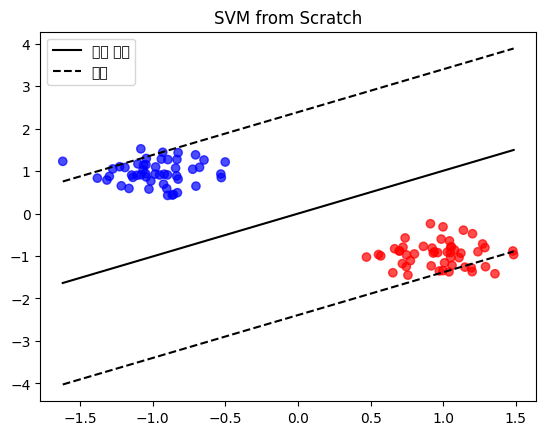

직접 구현 정확도: 1.000
sklearn 정확도:  1.000


In [19]:
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# 1. 데이터 생성
X, y = make_blobs(n_samples=100, centers=2, random_state=42)
y = np.where(y == 0, -1, 1)

# 2. 정규화 (SVM 필수)
scaler = StandardScaler()
X = scaler.fit_transform(X)

# 3. 학습
svm = SVM(lr=0.001, C = 1.0, n_iters=1000)
svm.fit(X, y)

# 4. 시각화
x_plot = np.linspace(X[:, 0].min(), X[:, 0].max(), 50)
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', alpha=0.7)
plt.plot(x_plot, svm.decision_boundary(x_plot),
         'k-', label='결정 경계')
upper, lower = svm.margin_lines(x_plot)
plt.plot(x_plot, upper, 'k--', label='마진')
plt.plot(x_plot, lower, 'k--')
plt.legend()
plt.title('SVM from Scratch')
plt.show()

# 5. sklearn과 비교
from sklearn.svm import SVC
sk_svm = SVC(kernel='linear', C=1.0).fit(X,y)
print(f"직접 구현 정확도: {np.mean(svm.predict(X) == y):.3f}")
print(f"sklearn 정확도:  {sk_svm.score(X, y):.3f}")